## Imports

In [1]:
import json
import gc
import optuna
import re
from datasets import load_dataset
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import r2_score, mean_absolute_error, mean_pinball_loss, make_scorer
from sklearn.ensemble import HistGradientBoostingRegressor
from tqdm import tqdm
from sklearn.linear_model import LinearRegression, Lasso
import mlflow
import mlflow.sklearn
from sklearn.model_selection import GroupKFold, RandomizedSearchCV, GridSearchCV, cross_validate
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.sparse import csr_matrix
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from nltk import word_tokenize, sent_tokenize
import seaborn as sns
sns.set_theme(context='paper', style = 'ticks', palette = 'bright')
sns.set_style('dark')
import matplotlib.pyplot as plt
import spacy
import joblib
from pathlib import Path
from collections import Counter
from features import CleanText, StylometricFeatures
from mapie.regression import MapieQuantileRegressor
import shap
import statsmodels
from data_cleaning import load_data, Corpus
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner', 'lemmatizer'])
nlp.add_pipe('sentencizer')

In [121]:
#set up words that will indicate a translation, which we exclude.

In [2]:
translation_words = ['Translator', 'France', 'French', 'German', 'Russia', 'Spain', 'Sweden', 'Swedish', 'Poland', 'Polish']
all_translation_words = []
for word in translation_words:
    all_translation_words.extend((word, word.lower()))

## Load Data

In [6]:
sample = load_data(all_translation_words, count = 2000)

Resolving data files:   0%|          | 0/37 [00:00<?, ?it/s]

4492it [01:45, 42.41it/s] 


In [7]:
df = Corpus(sample).clean_corpus(first_part_only = False)

## EDA

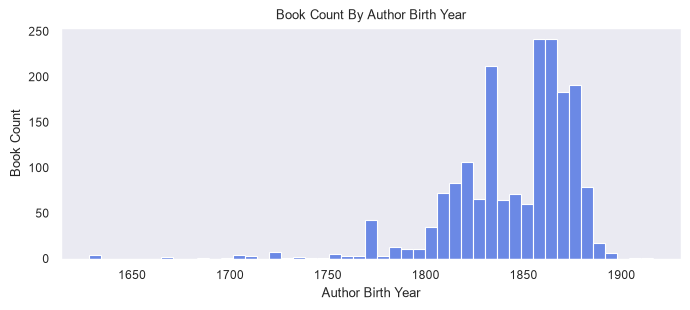

In [82]:
plt.figure(figsize=(8,3))
ax = sns.histplot(df[df.number ==1].birth_year, color='royalblue')
ax.set(xlabel = 'Author Birth Year', title = 'Book Count By Author Birth Year', ylabel = 'Book Count')
ax.figure.savefig(r"C:\Users\menac\PycharmProjects\Text Analysis\charts\books_by_author.png", bbox_inches = 'tight', pad_inches = 0.1)

[Text(0.5, 0, 'Author Birth Year'),
 Text(0.5, 1.0, 'Book Chunk Count By Author Birth Year')]

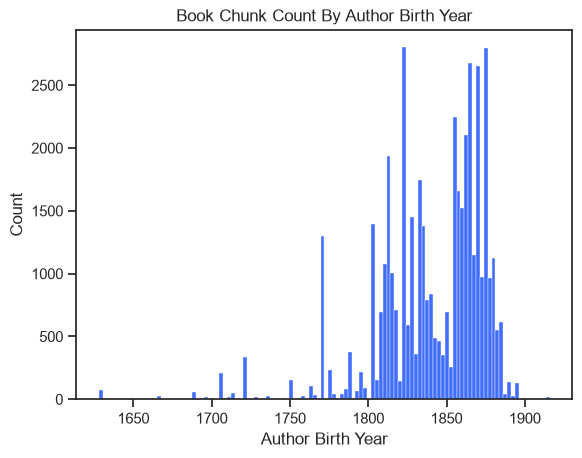

In [45]:
ax = sns.histplot(df.birth_year)
ax.set(xlabel = 'Author Birth Year', title = 'Book Chunk Count By Author Birth Year')

C:\Users\menac\AppData\Local\Temp\ipykernel_18536\2305519310.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ax = sns.histplot(df.drop_duplicates(subset = 'author') [df.number ==1].birth_year)


[Text(0.5, 0, 'Author Birth Year'), Text(0.5, 1.0, 'Unique Author Birth Year')]

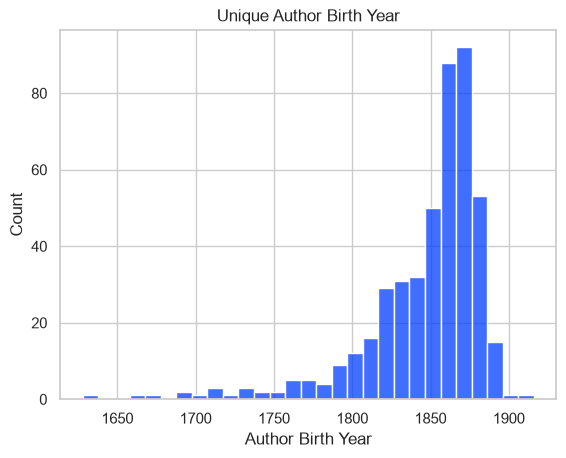

In [43]:
ax = sns.histplot(df.drop_duplicates(subset = 'author') [df.number ==1].birth_year)
ax.set(xlabel = 'Author Birth Year', title = 'Unique Author Birth Year')

[Text(0.5, 0, 'Author'),
 Text(0, 0.5, 'Count'),
 Text(0.5, 1.0, 'Books Per Author')]

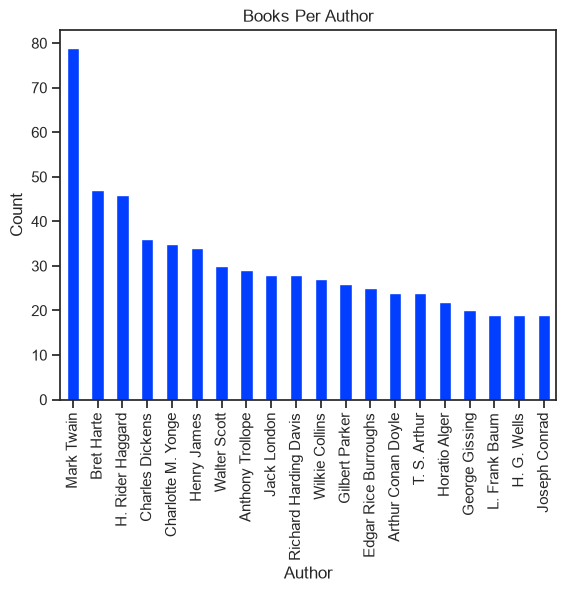

In [47]:
ax = df[df.number ==1].author.value_counts().iloc[:20].plot(kind = 'bar')
ax.set(xlabel = 'Author', ylabel = 'Count', title = 'Books Per Author')

## Model Training

### Set Splitting

1) We need to group the data by author, so that all of an author's texts are within one split. Otherwise, the model may learn individual writing characteristics of a particular author, and perform well on that author's works in the other splits, constituting a form of data leakage.
   
2) We need train, validation and test sets, as usual, but we also need a calibration set for the Conformal Quantile Regression fit. If we fit those quantile adjustment parameters on the train set then the parameters will be underestimated, as models typically perform unusually well on training sets.

In [562]:
# We first create the set indices and then apply them

In [13]:
gkf = GroupKFold(n_splits = 6)
train_index = np.array([], dtype = int)
calibrate_index = np.array([], dtype = int)
validate_index = np.array([], dtype = int)
test_index = np.array([], dtype = int)
for i, (indices1, indices2) in enumerate(gkf.split(df, groups=df.author)):
    
    if i <= 2:
        train_index = np.concatenate([train_index, indices2])
    elif i == 3:
        calibrate_index = np.concatenate([calibrate_index, indices2])
    elif i == 4:
        validate_index = np.concatenate([validate_index, indices2])
    else:
        test_index = np.concatenate([test_index, indices2])

X = df.drop(columns = ['birth_year'])
y = df['birth_year']

X_train, y_train = X.iloc[train_index], y.iloc[train_index]
X_calibrate, y_calibrate = X.iloc[calibrate_index], y.iloc[calibrate_index]
X_validate, y_validate = X.iloc[validate_index], y.iloc[validate_index]
X_test, y_test = X.iloc[test_index], y.iloc[test_index]

Create mini training set, consisting of only the first segment of each book, to calibrate hyperparameters

In [71]:
X_train_mini, y_train_mini = X_train[X_train['number'] == 1], y_train[X_train['number'] == 1]
# X_calibrate_mini, y_calibrate_mini = X_calibrate[X_calibrate['number'] == 1], y_calibrate[X_calibrate['number'] == 1]

### Optuna Hyperparameter Tuning

In [ ]:
# We will train the data prep pipeline and the median model using the optuna framework on the mini dataset, cross validated. We will then use the same hyperparameters
# and pipeline to train high and low models for confidence intervals.

In [4]:
n_trials = 15
with mlflow.start_run(run_name='experiment'):


    def objective(trial):
        model_params = {'l2_regularization': trial.suggest_float('l2_regularization', 1e-1, 100, log=True), 'learning_rate': trial.suggest_float('learning_rate', .05, 0.2),'max_iter': trial.suggest_int('max_iter', 50, 300),'max_leaf_nodes': trial.suggest_int('max_leaf_nodes', 15, 63)}

        tfidf_word_params = {'max_features': trial.suggest_int('max_features_word', 100, 3000), 'min_df': trial.suggest_float('min_df_word', 0.0, 0.2), 'max_df': trial.suggest_float('max_df_word', 0.8, 1.0)}

        tfidf_char_params = {'max_features': trial.suggest_int('max_features_char', 100, 3000), 'min_df': trial.suggest_float('min_df_char', 0.05, 0.2), 'max_df': trial.suggest_float('max_df_char', 0.8, 1.0)}

        ngram_low = trial.suggest_int('low', 3, 5)
        ngram_high = trial.suggest_int('high', 5,7)

        pipe = Pipeline([('clean_text', CleanText()), ('columns', ColumnTransformer([('features', FeatureUnion(
            [('stylo', StylometricFeatures()), ('tfidf', TfidfVectorizer(**tfidf_word_params)), ('tfidf_char', TfidfVectorizer(analyzer = 'char', ngram_range=(ngram_low, ngram_high), **tfidf_char_params))]), 'text')], remainder='drop', sparse_threshold=0)),
                         ('model', HistGradientBoostingRegressor(**model_params, early_stopping=True, n_iter_no_change=20, loss='quantile', quantile=0.5))])
        try:
            scores = cross_validate(pipe, X_train_mini, y_train_mini, groups=X_train_mini['author'],
                                scoring={'mae': 'neg_mean_absolute_error', 'r2': 'r2'}, cv=gkf, return_train_score=True)

            print(scores)
            trial.set_user_attr('r2', scores['test_r2'].mean())
        finally:
            gc.collect()
        return -scores['test_mae'].mean()

    median_param_path = Path('best_parameters.pkl')
    #if already have best parameters, load them, else run the experiment
    if median_param_path.exists():
        median_best_params = joblib.load(median_param_path)
        print('Params found and loaded.')
    else:
        print('Params not found. Recreating...')
        study = optuna.create_study(direction='minimize', sampler = optuna.samplers.TPESampler(seed=99))
        study.optimize(objective, n_trials=n_trials, timeout=30000)
        print(study.best_params)
        joblib.dump(study.best_params, median_param_path)
        median_best_params = study.best_params
        mlflow.log_metric('mae', study.best_value)
        mlflow.log_metric('r2', study.best_trial.user_attrs['r2'])
        mlflow.log_params(study.best_params)
        print(study.best_value)

Params found and loaded.


In [ ]:
# extract the data pipeline, to transform the datasets, in order to train the high and low models

In [5]:
data_prep = Pipeline([('clean_text', CleanText()), ('columns', ColumnTransformer([('features', FeatureUnion(
            [('stylo', StylometricFeatures()), ('tfidf', TfidfVectorizer(max_features = median_best_params['max_features_word'], min_df = median_best_params['min_df_word'], max_df = median_best_params['max_df_word'])), ('tfidf_char', TfidfVectorizer(analyzer = 'char', ngram_range=(median_best_params['low'], median_best_params['high']), max_features=median_best_params['max_features_char'], min_df = median_best_params['min_df_char'], max_df = median_best_params['max_df_char']))]), 'text')], remainder='drop'))])

In [ ]:
#transform X_train_mini, for hyperparameter tuning of high and low models

In [14]:
X_train_mini_features = data_prep.fit_transform(X_train_mini)
# X_calibrate_mini_features = data_prep.transform(X_calibrate_mini)

C:\Users\menac\PycharmProjects\Text Analysis\venv2\Lib\site-packages\numpy\core\fromnumeric.py:59: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)
C:\Users\menac\PycharmProjects\Text Analysis\venv2\Lib\site-packages\numpy\core\fromnumeric.py:59: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)


### High and Low Model Hyperparameter Tuning

In [89]:
mean_pinball_loss_high = make_scorer(mean_pinball_loss, alpha = 0.9)
with mlflow.start_run(run_name='experiment_high'):


    def objective(trial):
        model_params = {'l2_regularization': trial.suggest_float('l2_regularization', 1e-1, 100, log=True), 'learning_rate': trial.suggest_float('learning_rate', .05, 0.2),'max_iter': trial.suggest_int('max_iter', 50, 300),'max_leaf_nodes': trial.suggest_int('max_leaf_nodes', 15, 63)}

        high_model = HistGradientBoostingRegressor(**model_params, early_stopping=True, n_iter_no_change=20, loss='quantile', quantile=0.9)
        
        try:
            scores = cross_validate(high_model, X_train_mini_features, y_train_mini, groups=X_train_mini['author'],
                                scoring=mean_pinball_loss_high, cv=gkf)

            print(scores)
        finally:
            gc.collect()
        return scores['test_score'].mean()

    high_param_path = Path('best_params_high.pkl')
    #if already have best parameters, load them, else run the experiment
    if high_param_path.exists():
        high_best_params = joblib.load(high_param_path)
        print('Params found and loaded.')
    else:
        print('Params not found. Recreating...')
        study = optuna.create_study(direction='minimize', sampler = optuna.samplers.TPESampler(seed=42))
        study.optimize(objective, n_trials=n_trials, timeout=30000)
        print(study.best_params)
        joblib.dump(study.best_params, high_param_path)
        high_best_params = study.best_params
        mlflow.log_metric('mpl', study.best_value)
        mlflow.log_params(study.best_params)
        print(study.best_value)

Params found and loaded.


In [90]:
mean_pinball_loss_low = make_scorer(mean_pinball_loss, alpha = 0.1)
with mlflow.start_run(run_name='experiment_high'):


    def objective(trial):
        model_params = {'l2_regularization': trial.suggest_float('l2_regularization', 1e-1, 100, log=True), 'learning_rate': trial.suggest_float('learning_rate', .05, 0.2),'max_iter': trial.suggest_int('max_iter', 50, 300),'max_leaf_nodes': trial.suggest_int('max_leaf_nodes', 15, 63)}

        low_model = HistGradientBoostingRegressor(**model_params, early_stopping=True, n_iter_no_change=20, loss='quantile', quantile=0.1)
        
        try:
            scores = cross_validate(low_model, X_train_mini_features, y_train_mini, groups=X_train_mini['author'],
                                scoring=mean_pinball_loss_low, cv=gkf)

            print(scores)
        finally:
            gc.collect()
        return scores['test_score'].mean()

    low_param_path = Path('best_params_low.pkl')
    #if already have best parameters, load them, else run the experiment
    if low_param_path.exists():
        low_best_params = joblib.load(low_param_path)
        print('Params found and loaded.')
    else:
        print('Params not found. Recreating...')
        study = optuna.create_study(direction='minimize', sampler = optuna.samplers.TPESampler(seed=42))
        study.optimize(objective, n_trials=n_trials, timeout=30000)
        print(study.best_params)
        joblib.dump(study.best_params, low_param_path)
        Low_best_params = study.best_params
        mlflow.log_metric('mpl', study.best_value)
        mlflow.log_params(study.best_params)
        print(study.best_value)

Params found and loaded.


In [120]:
# Transform and store training features

In [84]:
X_train_features = data_prep.fit_transform(X_train)
pd.DataFrame(X_train_features, columns = data_prep.named_steps['columns'].named_transformers_['features'].get_feature_names_out()).to_parquet('X_train_features.parquet')

In [ ]:
## remove stop words to compress data prep model before pickling

In [186]:
data_prep.named_steps['columns'].transformers_[0][1].transformer_list[2][1].stop_words_ = set()
data_prep.named_steps['columns'].transformers_[0][1].transformer_list[1][1].stop_words_ = set()

In [187]:
joblib.dump(data_prep, Path('data_prep.pkl'))

['data_prep.pkl']

### Model Training on Full Training Set

In [91]:
median_model = HistGradientBoostingRegressor(learning_rate = median_best_params['learning_rate'], max_iter = median_best_params['max_iter'], l2_regularization = median_best_params['l2_regularization'], max_leaf_nodes = median_best_params['max_leaf_nodes'],early_stopping=True, n_iter_no_change=20, loss='quantile', quantile=0.5)
median_model.fit(X_train_features, y_train)

HistGradientBoostingRegressor(early_stopping=True,
                              l2_regularization=0.5346598636778399,
                              learning_rate=0.05226811691754492,
                              loss='quantile', max_iter=300, max_leaf_nodes=44,
                              n_iter_no_change=20, quantile=0.5)

In [92]:
joblib.dump(median_model, Path('median_model.pkl'))

['median_model.pkl']

In [95]:
high_model = HistGradientBoostingRegressor(learning_rate = high_best_params['learning_rate'], max_iter = high_best_params['max_iter'], l2_regularization = high_best_params['l2_regularization'], max_leaf_nodes = high_best_params['max_leaf_nodes'],early_stopping=False, n_iter_no_change=50, loss='quantile', quantile=0.9)
high_model.fit(X_train_features, y_train)

HistGradientBoostingRegressor(early_stopping=False,
                              l2_regularization=6.847920095574778,
                              learning_rate=0.07092407909780628,
                              loss='quantile', max_iter=123, max_leaf_nodes=32,
                              n_iter_no_change=50, quantile=0.9)

In [96]:
joblib.dump(high_model, Path('high_model.pkl'))

['high_model.pkl']

In [97]:
low_model = HistGradientBoostingRegressor(learning_rate = low_best_params['learning_rate'], max_iter = low_best_params['max_iter'], l2_regularization = low_best_params['l2_regularization'], max_leaf_nodes = low_best_params['max_leaf_nodes'],early_stopping=False, n_iter_no_change=50, loss='quantile', quantile=0.1)
low_model.fit(X_train_features, y_train)
joblib.dump(low_model, Path('low_model.pkl'))

['low_model.pkl']

### CQR Training

In [ ]:
#transform X_calibrate, for CQR fitting

In [ ]:
X_calibrate_features = data_prep.transform(X_calibrate)
pd.DataFrame(X_calibrate_features, columns = data_prep.named_steps['columns'].named_transformers_['features'].get_feature_names_out()).to_parquet('X_calibrate_features.parquet')

In [361]:
mqr = MapieQuantileRegressor(estimator = [low_model, high_model, median_model], alpha = 0.2, cv = 'prefit')

In [362]:
mqr.fit(X_calibrate_features, y_calibrate)

MapieQuantileRegressor(alpha=0.2, cv='prefit',
                       estimator=[HistGradientBoostingRegressor(early_stopping=False,
                                                                l2_regularization=3.621515816414695,
                                                                learning_rate=0.09782925071963341,
                                                                loss='quantile',
                                                                max_iter=142,
                                                                max_leaf_nodes=55,
                                                                n_iter_no_change=50,
                                                                quantile=0.1),
                                  HistGradientBoostingRegressor(early_stopping=False,
                                                                l2_regularization=6.847920095574778,
                                                                learning_rate=0.07092407909780628,
                                                                loss='quantile',
                                                                max_iter=123,
                                                                max_leaf_nodes=32,
                                                                n_iter_no_change=50,
                                                                quantile=0.9),
                                  HistGradientBoostingRegressor(early_stopping=True,
                                                                l2_regularization=0.5346598636778399,
                                                                learning_rate=0.05226811691754492,
                                                                loss='quantile',
                                                                max_iter=300,
                                                                max_leaf_nodes=44,
                                                                n_iter_no_change=20,
                                                                quantile=0.5)])

In [363]:
joblib.dump(mqr, Path('mqr.pkl'))

['mqr.pkl']

In [9]:
mqr = joblib.load(Path('mqr.pkl'))

In [254]:
X_validate_features = data_prep.transform(X_validate)
pd.DataFrame(X_validate_features, columns = data_prep.named_steps['columns'].named_transformers_['features'].get_feature_names_out()).to_parquet('X_validate_features.parquet')

C:\Users\menac\PycharmProjects\Text Analysis\venv2\Lib\site-packages\numpy\core\fromnumeric.py:59: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)


________________________________________________________________________________
[Memory] Calling features.stylo_chunk...
stylo_chunk(131     expedition. They needed a\n\ndoctor, and that ...
132     a land in a state of\n\nperfect cultivation, w...
133     very much on the stage, and\n\nyet any one of ...
134     the days passed. He seemed to mind our confine...
135     boat!”\n\nSure enough—there was our motor, lyi...
                              ...                        
1705    gainst the election; and\n\nso many people cam...
1706    se and\n\nthe furniture.\n\nThis specimen of t...
1707    omfort we have in such long separations. Yes,\...
1708    e carrying your disinterestedness\n\nbeyond re...
1709    th such zealous attention, as to ascertain wha...
Name: text, Length: 309, dtype: object)


100%|██████████| 309/309 [00:49<00:00,  6.20it/s]


_____________________________________________________stylo_chunk - 49.7s, 0.8min
________________________________________________________________________________
[Memory] Calling features.stylo_chunk...
stylo_chunk(1710    company of her mother and cousins the\n\nfollo...
1711    dingly, by\n\nhoping, with a laugh, that she w...
1712    an hour\n\nago, and she was told it by a parti...
1713    now she could reproach her only\n\nby the tear...
1714    is designs might once have been on herself, pr...
                              ...                        
3979    I can make that do. Thank\n\nyou—sorry to trou...
3980    ned to talk only to Hilda, who was walking bet...
3981    afterward. Why spoil our afternoon?"\n\nBraune...
3982    ouse. And within, also, it was of a\n\nfamilia...
3983    ur wife?"\n\n"I want revenge."\n\n"Of course—c...
Name: text, Length: 309, dtype: object)


100%|██████████| 309/309 [00:43<00:00,  7.16it/s]


...

____________________________________________________stylo_chunk - 221.5s, 3.7min
________________________________________________________________________________
[Memory] Calling features.stylo_chunk...
stylo_chunk(41315    g this section of the inhabitants of\n\nCamalo...
41316    lled upon their men to draw off and leave a sp...
41317    nt at the council, to which only a few\n\nof t...
41318    had suddenly been attacked and that many had f...
41319    that\n\nSuetonius would give battle before the...
                               ...                        
42488    " thundered Mole.\n\n"I'll be your slave, your...
42489    been taught to look upon as\n\nbrothers."\n\nS...
42490    l this time we might have been spared the bitt...
42491    t that very moment Harkaway was nearly distrac...
42492    , and rushed up joyfully to Harry\n\nGirdwood....
Name: text, Length: 308, dtype: object)


100%|██████████| 308/308 [03:38<00:00,  1.41it/s]


____________________________________________________stylo_chunk - 218.3s, 3.6min
________________________________________________________________________________
[Memory] Calling features.stylo_chunk...
stylo_chunk(42493    ated and appeared ready to start from\n\ntheir...
42494    FORE WITH A FRESH FEAT ON\n\nTHE LONGBOW.\n\n"...
42495    no one has better reason than you to know that...
42496    Jack began to haul in the line, coiling it dow...
42497    men of\n\nwhom Joe Basalt had spoken.\n\nNot a...
                               ...                        
43724    s one that she could save? What if she, who ha...
43725    ew that, to a certain\n\n point, self-confiden...
43726    a kind of extended egotism. Love had narrowed ...
43727    e,” he called to her as the door closed on him...
43728    by Miss Verney’s reply to the anxious assevera...
Name: text, Length: 308, dtype: object)


100%|██████████| 308/308 [03:39<00:00,  1.40it/s]


____________________________________________________stylo_chunk - 219.6s, 3.7min


## Results Analysis

In [105]:
lower = y_validate_pis[:,0,:].reshape(-1)
upper = y_validate_pis[:,1,:].reshape(-1)
results_df = pd.DataFrame(y_validate.values, columns = ['act_yr'])
results_df['pred_yr'] = y_validate_pred
results_df['resid'] = results_df['act_yr'] - results_df['pred_yr']
results_df['abs_resid'] = abs(results_df['act_yr'] - results_df['pred_yr'])
results_df['lower'] = lower
results_df['upper'] = upper
results_df['pi_width'] = results_df.upper - results_df.lower
results_df['within_pi'] = (results_df['act_yr'] <= results_df['upper']) & (results_df['act_yr'] >= results_df['lower'])

In [118]:
print(f"MAE is {round(mean_absolute_error(results_df.act_yr, results_df.pred_yr),3)}")
print(f"R2 is {round(r2_score(results_df.act_yr, results_df.pred_yr),3)}")
print(f"PI Coverage is {round(np.mean((results_df.act_yr <= results_df.upper) & (results_df.act_yr >= results_df.lower)),3)}")

MAE is 14.834
R2 is 0.505
PI Coverage is 0.734


### Charts

In [45]:
names_raw = data_prep.named_steps['columns'].named_transformers_['features'].get_feature_names_out()
features = data_prep.named_steps['columns'].named_transformers_['features']
names_raw = data_prep.named_steps['columns'].named_transformers_['features'].get_feature_names_out()
names = [name.replace('stylo__', '').replace('tfidf_char__', '').replace('tfidf__', '') for name in names_raw]
explainer = shap.TreeExplainer(mqr.estimators_[2])
shap_values = explainer(X_validate_features)

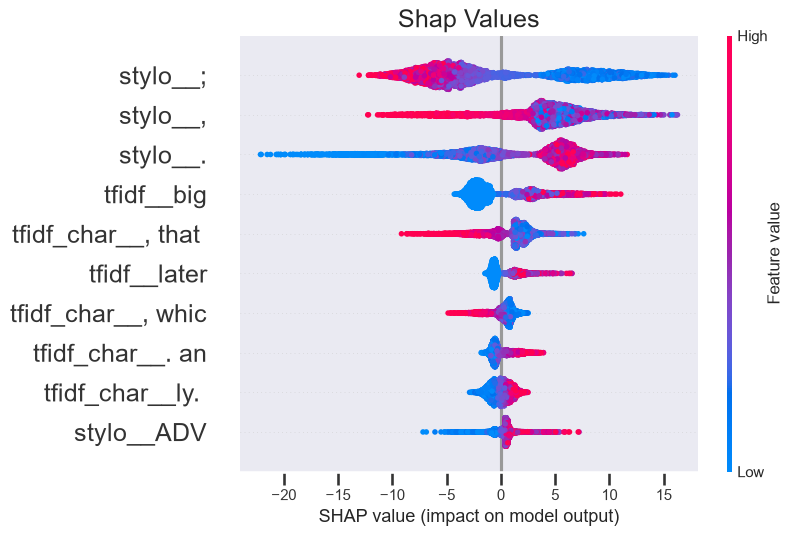

In [78]:
plt.figure(figsize=(8,3))
shap.summary_plot(shap_values, X_validate_features, names_raw, show=False, max_display = 10)
plt.yticks(fontsize = 18)
plt.title('Shap Values')
plt.savefig(r"C:\Users\menac\PycharmProjects\Text Analysis\charts\shap.png", bbox_inches = 'tight', pad_inches = 0.1)

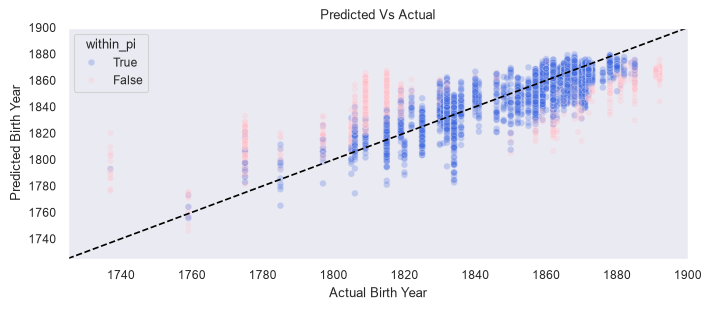

In [83]:
ax = plt.figure(figsize=(8,3))
sns.scatterplot(data=results_df, x='act_yr', y='pred_yr', alpha = 0.25, hue='within_pi', hue_order=[True, False], palette=['royalblue', 'pink'])
plt.xlim(1725, 1900)
plt.ylim(1725, 1900)
plt.axline(xy1=(1800,1800), slope = 1, linestyle = '--', color = 'black')
plt.xlabel('Actual Birth Year')
plt.ylabel('Predicted Birth Year')
plt.title('Predicted Vs Actual')
plt.savefig(r"C:\Users\menac\PycharmProjects\Text Analysis\charts\actual_vs_pred.png", bbox_inches = 'tight', pad_inches = 0.1)

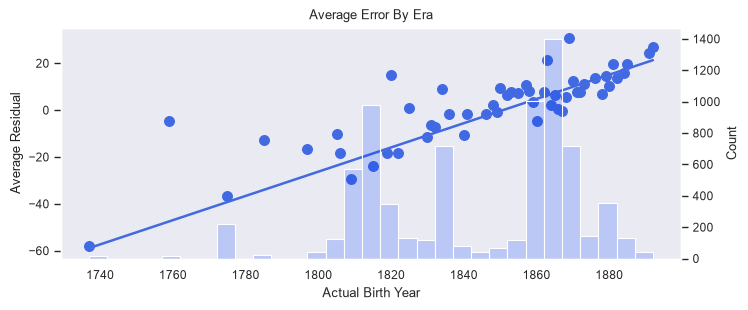

In [84]:
plt.figure(figsize=(8,3))
ax = sns.regplot(data=results_df, x = 'act_yr', y='resid', x_bins = results_df.act_yr.unique(), ci=0, color='royalblue')

plt.xlabel('Actual Birth Year')
plt.ylabel('Average Residual')
plt.title('Average Error By Era')
sns.histplot(results_df.act_yr, ax=ax.twinx(), alpha = 0.2)

plt.savefig(r"C:\Users\menac\PycharmProjects\Text Analysis\charts\error_by_era.png", bbox_inches = 'tight', pad_inches = 0.1)

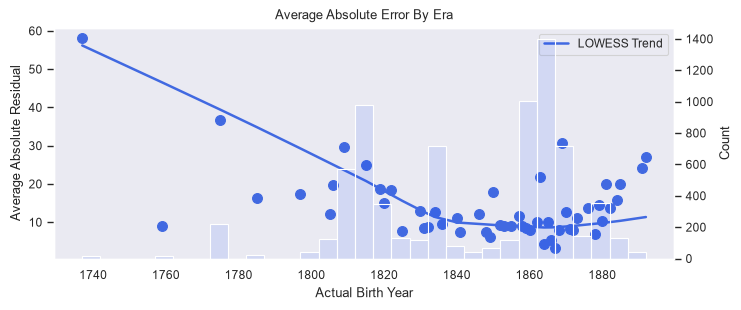

In [85]:
plt.figure(figsize=(8,3))
ax=sns.regplot(data=results_df, x = 'act_yr', y='abs_resid', x_bins = results_df.act_yr.unique(), ci=0, color='royalblue', lowess=True,
              line_kws={'label':'LOWESS Trend'})
plt.xlabel('Actual Birth Year')
plt.ylabel('Average Absolute Residual')
plt.title('Average Absolute Error By Era')
plt.legend()
sns.histplot(results_df.act_yr, ax=ax.twinx(), alpha = 0.1)
plt.savefig(r"C:\Users\menac\PycharmProjects\Text Analysis\charts\mae_by_era.png", bbox_inches = 'tight', pad_inches = 0.1)

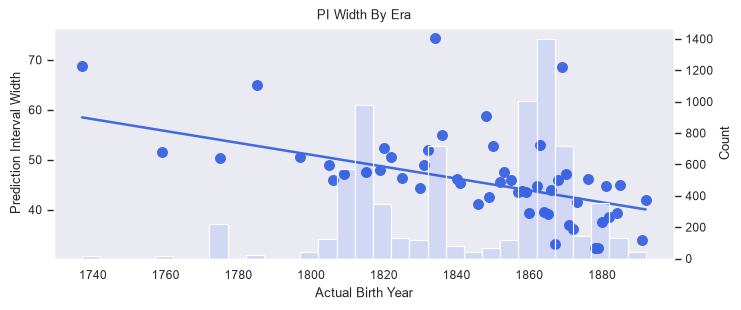

In [86]:
plt.figure(figsize=(8,3))
ax=sns.regplot(data=results_df, x = 'act_yr', y='pi_width', x_bins = results_df.act_yr.unique(), ci=0, color='royalblue')
plt.xlabel('Actual Birth Year')
plt.ylabel('Prediction Interval Width')
plt.title('PI Width By Era')
sns.histplot(results_df.act_yr, ax=ax.twinx(), alpha = 0.1)
plt.savefig(r"C:\Users\menac\PycharmProjects\Text Analysis\charts\pi_width.png", bbox_inches = 'tight', pad_inches = 0.1)

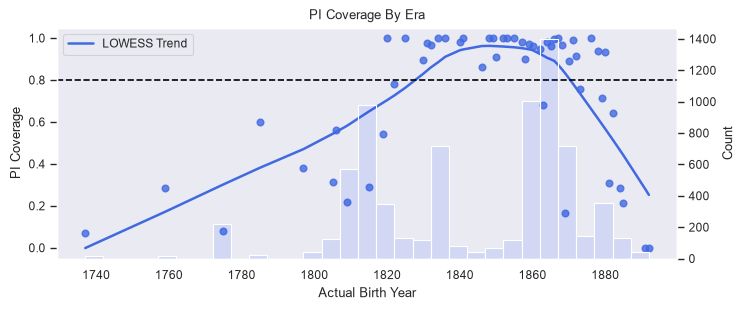

In [87]:
plt.figure(figsize=(8,3))
ax=sns.regplot(y=results_df.groupby('act_yr')['within_pi'].mean(), x = results_df.groupby('act_yr')['within_pi'].mean().keys(),  color='royalblue', 
               lowess=True, line_kws={'label':'LOWESS Trend'})
plt.axline(xy1=(1750,0.8), slope=0, linestyle='--', color='black')
plt.xlabel('Actual Birth Year')
plt.ylabel('PI Coverage')
plt.title('PI Coverage By Era')
plt.legend()
sns.histplot(results_df.act_yr, ax=ax.twinx(), alpha = 0.1)
plt.savefig(r"C:\Users\menac\PycharmProjects\Text Analysis\charts\pi_coverage_by_era.png", bbox_inches = 'tight', pad_inches = 0.1)

## Finishing Touches

In [ ]:
## train a standard scaler purely to help interpret the shap chart. Makes no difference to a tree-based model.

In [501]:
display_scaler = StandardScaler()
display_scaler.fit(X_train_features)
joblib.dump(display_scaler, 'display_scaler.pkl')

['display_scaler.pkl']

In [119]:
# additional test set preserved in case future improvements are needed.

In [255]:
X_test_features = data_prep.transform(X_test)
pd.DataFrame(X_test_features, columns = data_prep.named_steps['columns'].named_transformers_['features'].get_feature_names_out()).to_parquet('X_test_features.parquet')

C:\Users\menac\PycharmProjects\Text Analysis\venv2\Lib\site-packages\numpy\core\fromnumeric.py:59: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)


________________________________________________________________________________
[Memory] Calling features.stylo_chunk...
stylo_chunk(196     a continual reverie. They\n\nare given to all ...
197     h, and the money invested in immense tracts of...
198     eed Daredevil, a creature, like himself, full ...
711     wore,\n\nher white gloves, and, curiously enou...
712     of the way,”\n\nhe said, laughing. “Winifred, ...
                              ...                        
2425    these men to\n\nbe more than a match for the o...
2426    ong shrivelled members of her companion. On th...
2427    ed furiously away, never even looking round, a...
2428    sobbed at the thought of his own\n\nimpotence....
2429    veness, which he may have learned\n\nfrom the ...
Name: text, Length: 309, dtype: object)


100%|██████████| 309/309 [03:52<00:00,  1.33it/s]


____________________________________________________stylo_chunk - 232.2s, 3.9min
________________________________________________________________________________
[Memory] Calling features.stylo_chunk...
stylo_chunk(2430    wed it, and drove off. I whipped up my horse a...
2569    s growing pale. Dawn was coming in greyly thro...
2570    “There is no reason to explain anything,” she ...
2571    YOUR DEBAUCHERIES, TORN TIER FROM TIER, AND ST...
2572    yramids and palaces, the like of which for spl...
                              ...                        
3817    iddle\n\nWest in the years after the Civil War...
3818    e in the house in Winesburg and of his mother’...
3819    studies,” she heard Harriet saying to her sist...
3820    ardly\n\nbelieve my own eyes. It hasn’t rained...
3821    look down the deserted street and thought of t...
Name: text, Length: 309, dtype: object)


100%|██████████| 309/309 [03:35<00:00,  1.44it/s]


...

____________________________________________________stylo_chunk - 220.4s, 3.7min
________________________________________________________________________________
[Memory] Calling features.stylo_chunk...
stylo_chunk(43777    s\n\n pretty sure to be the dupe. But in those...
43778    blue-and-white flower-pot, and you could\n\n h...
43779    e clear\n\n instincts of truth in our accursed...
43780    nthusiasm and convincing calculation. Dicaeopo...
43781    e Jack, approvingly. “True, my boy.\n\n But in...
                               ...                        
44080    lives of saint or martyr (though a hundred vol...
44081    ondly at the infant; “it is my\n\n all!”\n\n \...
44082    for that.”\n\n \n\n “Oh, no—no!”\n\n \n\n “But...
44083    hen conducted her to the rich man’s residence....
44084    he entertained towards her, were of a very com...
Name: text, Length: 308, dtype: object)


100%|██████████| 308/308 [03:23<00:00,  1.51it/s]


____________________________________________________stylo_chunk - 203.3s, 3.4min
________________________________________________________________________________
[Memory] Calling features.stylo_chunk...
stylo_chunk(44085    the spot. The banker\n\n involuntarily followe...
44086    him to proceed. To stop short is to fail. He h...
44087    with the literary exclusives. They\n\n even be...
44088    shall soon part again, let me now tell you\n\n...
44089    s dishonoured by\n\n the contact.\n\n \n\n Wit...
                               ...                        
44388    n, colourless\n\n face, and wrenched from him ...
44389    e for\n\n terminating our visit?”\n\n \n\n “Bu...
44390    morn, though night still is at her full. Moonb...
44391    hts. I will send for the physician.”\n\n \n\n ...
44392    ed when Varney proposed, as his obvious and\n\...
Name: text, Length: 308, dtype: object)


100%|██████████| 308/308 [03:21<00:00,  1.53it/s]


____________________________________________________stylo_chunk - 201.3s, 3.4min
